# Pedestrian Detection using OpenCV

## 1. Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version:  {np.__version__}")
print("Computer Vision environment initialized successfully!")

OpenCV Version: 4.11.0
NumPy Version:  2.4.1
Computer Vision environment initialized successfully!


## 2. HOG + SVM Architecture Overview

## 3. Load Street Scenes

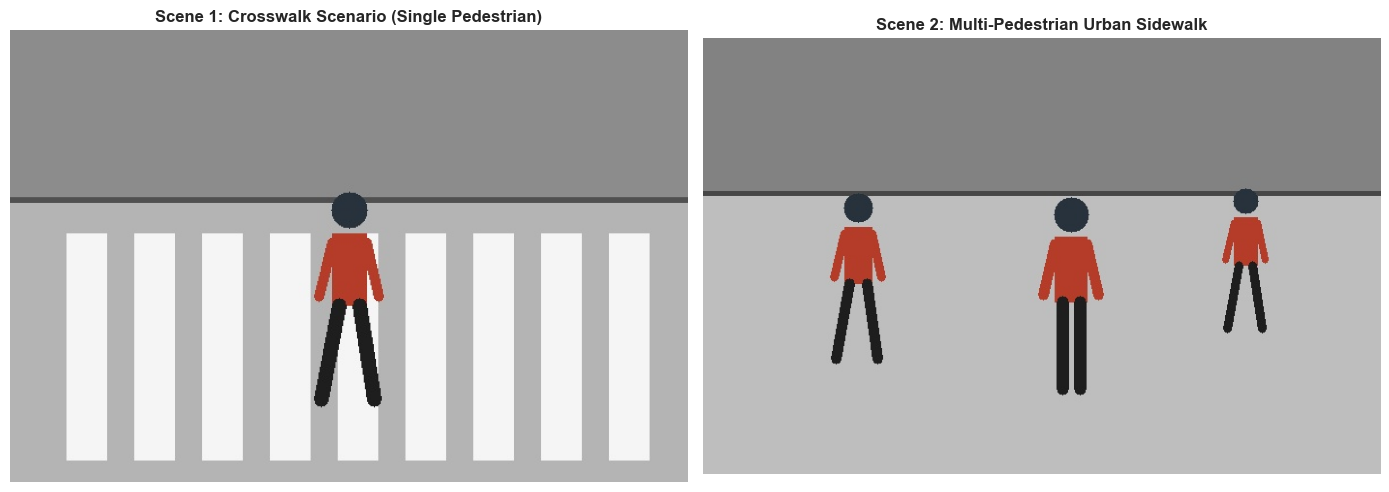

In [2]:
# Load test scenes
scene1_bgr = cv2.imread('test_images/scene1_crosswalk.jpg')
scene2_bgr = cv2.imread('test_images/scene2_multipedestrians.jpg')

# Convert BGR to RGB for matplotlib display
scene1_rgb = cv2.cvtColor(scene1_bgr, cv2.COLOR_BGR2RGB)
scene2_rgb = cv2.cvtColor(scene2_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(scene1_rgb)
axes[0].set_title('Scene 1: Crosswalk Scenario (Single Pedestrian)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(scene2_rgb)
axes[1].set_title('Scene 2: Multi-Pedestrian Urban Sidewalk', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. HOG Gradient Magnitude & Orientation Visualization

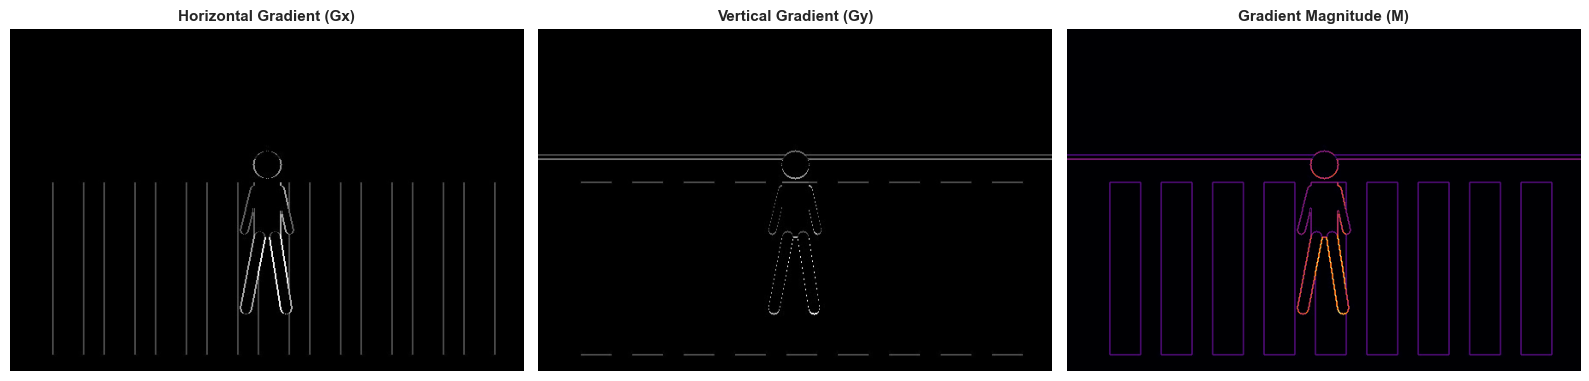

In [3]:
# Compute gradients on grayscale scene
gray_scene = cv2.cvtColor(scene1_bgr, cv2.COLOR_BGR2GRAY)

# Sobel Gradients
gx = cv2.Sobel(gray_scene, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(gray_scene, cv2.CV_32F, 0, 1, ksize=1)

# Magnitude and Angle
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].imshow(np.abs(gx), cmap='gray')
axes[0].set_title('Horizontal Gradient (Gx)', fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(np.abs(gy), cmap='gray')
axes[1].set_title('Vertical Gradient (Gy)', fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(mag, cmap='inferno')
axes[2].set_title('Gradient Magnitude (M)', fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 5. Pre-Trained OpenCV HOG + SVM People Detector

In [4]:
# Initialize HOG Descriptor
hog = cv2.HOGDescriptor()

# Set the pre-trained SVM detector coefficients
svm_detector = cv2.HOGDescriptor_getDefaultPeopleDetector()
hog.setSVMDetector(svm_detector)

print(f"HOG Descriptor Initialized:")
print(f"  Window Size:       {hog.winSize} (Width x Height)")
print(f"  Block Size:        {hog.blockSize}")
print(f"  Block Stride:      {hog.blockStride}")
print(f"  Cell Size:         {hog.cellSize}")
print(f"  Bins:              {hog.nbins}")
print(f"  SVM Vector Length: {len(svm_detector)} coefficients")

HOG Descriptor Initialized:
  Window Size:       (64, 128) (Width x Height)
  Block Size:        (16, 16)
  Block Stride:      (8, 8)
  Cell Size:         (8, 8)
  Bins:              9
  SVM Vector Length: 3781 coefficients


## 6. Multi-Scale Pedestrian Detection

In [5]:
# Detect pedestrians on Scene 1
boxes_raw1, weights_raw1 = hog.detectMultiScale(
    scene1_bgr,
    winStride=(4, 4),
    padding=(8, 8),
    scale=1.05
)

print(f"Scene 1 Detections: {len(boxes_raw1)} bounding boxes found.")
for i, (b, w) in enumerate(zip(boxes_raw1, weights_raw1), 1):
    print(f"  Detection {i}: [x={b[0]}, y={b[1]}, w={b[2]}, h={b[3]}], Confidence Weight: {w:.2f}")

Scene 1 Detections: 1 bounding boxes found.
  Detection 1: [x=240, y=119, w=122, h=243], Confidence Weight: 2.90


## 7. Non-Maximum Suppression (NMS)

In [6]:
def non_max_suppression(boxes, weights, overlap_thresh=0.3):
    """
    Applies Non-Maximum Suppression (NMS) to eliminate duplicate bounding boxes.
    boxes: array of [x, y, w, h]
    weights: array of confidence scores
    """
    if len(boxes) == 0:
        return [], []

    boxes = np.array(boxes, dtype=float)
    weights = np.array(weights, dtype=float).flatten()

    # Convert [x, y, w, h] to [x1, y1, x2, y2]
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]

    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(weights) # sort by confidence

    pick = []

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        # Compute IoU with remaining boxes
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        overlap = (w * h) / area[idxs[:last]]

        # Delete indices with overlap greater than threshold
        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlap_thresh)[0])))

    return boxes[pick].astype(int), weights[pick]

print("Non-Maximum Suppression (NMS) function defined.")

Non-Maximum Suppression (NMS) function defined.


## 8. Detection Results Visualization

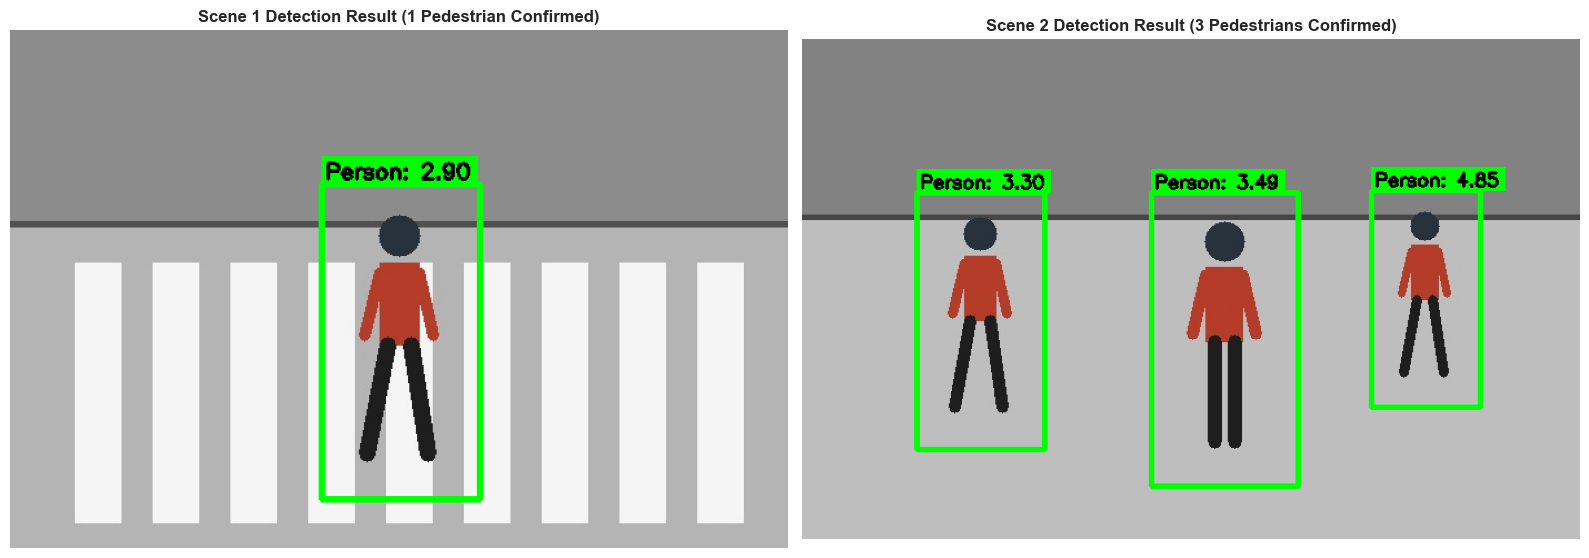

In [7]:
def draw_detections(image_rgb, boxes, weights, color=(0, 255, 0), label_prefix="Person"):
    img_draw = image_rgb.copy()
    for (x, y, w, h), conf in zip(boxes, weights):
        cv2.rectangle(img_draw, (x, y), (x + w, y + h), color, 3)
        # Background box for label text
        label = f"{label_prefix}: {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(img_draw, (x, y - th - 8), (x + tw + 6, y), color, -1)
        cv2.putText(img_draw, label, (x + 3, y - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)
    return img_draw

# Run detections on Scene 2
boxes_raw2, weights_raw2 = hog.detectMultiScale(scene2_bgr, winStride=(4, 4), padding=(8, 8), scale=1.05)
boxes_nms2, weights_nms2 = non_max_suppression(boxes_raw2, weights_raw2, overlap_thresh=0.3)
boxes_nms1, weights_nms1 = non_max_suppression(boxes_raw1, weights_raw1, overlap_thresh=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scene 1 NMS result
vis_scene1 = draw_detections(scene1_rgb, boxes_nms1, weights_nms1, color=(0, 255, 0))
axes[0].imshow(vis_scene1)
axes[0].set_title(f'Scene 1 Detection Result ({len(boxes_nms1)} Pedestrian Confirmed)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Scene 2 NMS result
vis_scene2 = draw_detections(scene2_rgb, boxes_nms2, weights_nms2, color=(0, 255, 0))
axes[1].imshow(vis_scene2)
axes[1].set_title(f'Scene 2 Detection Result ({len(boxes_nms2)} Pedestrians Confirmed)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 9. Real-Time Latency & FPS Benchmark

In [8]:
# Benchmark detection speed over 15 iterations
iterations = 15
latencies = []

for _ in range(iterations):
    t0 = time.time()
    boxes, weights = hog.detectMultiScale(scene2_bgr, winStride=(4, 4), padding=(8, 8), scale=1.05)
    _ = non_max_suppression(boxes, weights, overlap_thresh=0.3)
    latencies.append(time.time() - t0)

avg_latency = np.mean(latencies)
fps = 1.0 / avg_latency

print("=== HOG + SVM Inference Latency Benchmark ===")
print(f"  Mean Frame Processing Time: {avg_latency * 1000:.2f} ms")
print(f"  Effective Throughput:       {fps:.2f} FPS")
print(f"  Frame Resolution:           {scene2_bgr.shape[1]} x {scene2_bgr.shape[0]} px")

=== HOG + SVM Inference Latency Benchmark ===
  Mean Frame Processing Time: 283.90 ms
  Effective Throughput:       3.52 FPS
  Frame Resolution:           700 x 450 px


## 10. Reusable Pedestrian Detection Pipeline

In [9]:
def detect_pedestrians(image_path_or_array, min_confidence=0.5, win_stride=(4, 4), scale=1.05):
    """
    Complete end-to-end pedestrian detection pipeline.
    image_path_or_array: file path string or numpy BGR/RGB image array
    Returns: annotated RGB image, detected bounding boxes, confidence weights
    """
    if isinstance(image_path_or_array, str):
        img_bgr = cv2.imread(image_path_or_array)
    else:
        img_bgr = image_path_or_array.copy()
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 1. MultiScale HOG Detection
    boxes, weights = hog.detectMultiScale(
        img_bgr,
        winStride=win_stride,
        padding=(8, 8),
        scale=scale
    )
    
    # 2. Confidence Filtering
    if len(boxes) > 0:
        valid_mask = weights.flatten() >= min_confidence
        boxes = boxes[valid_mask]
        weights = weights.flatten()[valid_mask]
    
    # 3. Non-Maximum Suppression
    boxes_clean, weights_clean = non_max_suppression(boxes, weights, overlap_thresh=0.3)
    
    # 4. Render Annotations
    annotated = draw_detections(img_rgb, boxes_clean, weights_clean, color=(0, 255, 0))
    
    return annotated, boxes_clean, weights_clean

# Test pipeline on Scene 2
annotated_img, final_boxes, final_weights = detect_pedestrians('test_images/scene2_multipedestrians.jpg', min_confidence=1.0)
print(f"Pipeline executed successfully. Verified {len(final_boxes)} pedestrians with confidence >= 1.0.")

Pipeline executed successfully. Verified 3 pedestrians with confidence >= 1.0.
